Objective
To gain understanding of single linear regression through implementing the model from
scratch
Tasks
• Read the data from above mentioned dataset and define X and y as numpy array
• Add column at position 0 with all values=1 (pandas.DataFrame.insert function)
• Print rows from 40 to 55.
• Print the shape and datatype of both X and y
• Implement simple linear regression from scratch
o Write hypothesis function to predict values
o Write function for calculating mean_squared_error
o Write function to return gradients for given weights

o Perform gradient descent taking help of above functions
• Remove outliers, train again and see the difference in error.
• Replace "weights = np.random.rand(2)" line in gradient descent with below line,
train again and visualize results.
• Play with learning rate and max_iterations
• Generalize the code for multivariate(multiple) linear regression

In [1]:
import pandas as pd 
import numpy as np 

url = "https://github.com/mishravipul/data/raw/main/multiple_linear_data.csv"

df = pd.read_csv(url)

df

,age,address,famsize,reason,studytime,failures,schoolsup,famsup,paid,activities,higher,internet,romantic,freetime,goout,health,absences,G1,G2,G3
0,18,U,GT3,course,2,0,yes,no,no,no,yes,no,no,3,4,3,6,25,30,30
1,17,U,GT3,course,2,0,no,yes,no,no,yes,yes,no,3,3,3,4,25,25,30
2,15,U,LE3,other,2,3,yes,no,yes,no,yes,yes,no,3,2,3,10,35,40,50
3,15,U,GT3,home,3,0,no,yes,yes,yes,yes,yes,yes,2,2,5,2,75,70,75
4,16,U,GT3,home,2,0,no,yes,yes,no,yes,no,no,3,2,5,4,30,50,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,20,U,LE3,course,2,2,no,yes,yes,no,yes,no,no,5,4,4,11,45,45,45
391,17,U,LE3,course,1,0,no,no,no,no,yes,yes,no,4,5,2,3,70,80,80
392,21,R,GT3,course,1,3,no,no,no,no,yes,no,no,5,3,3,3,50,40,35
393,18,R,LE3,course,1,0,no,no,no,no,yes,yes,no,4,1,5,0,55,60,50


In [2]:
X = df[['intercept', 'G2']].to_numpy()
Y = df['G3'].to_numpy()

print(f"Shape of X: {X.shape}")  
print(f"Shape of Y: {Y.shape}")  

KeyError: "['intercept'] not in index"

In [ ]:
df.insert(0,'intercept',1)
df.iloc[40:56]

,intercept,age,address,famsize,reason,studytime,failures,schoolsup,famsup,paid,...,higher,internet,romantic,freetime,goout,health,absences,G1,G2,G3
40,1,16,U,LE3,home,2,1,no,yes,no,...,yes,yes,yes,3,3,3,25,35,50,55
41,1,15,U,LE3,home,1,0,no,yes,no,...,yes,yes,yes,4,3,5,8,60,60,60
42,1,15,U,GT3,course,2,0,no,yes,no,...,yes,yes,no,3,3,5,2,95,90,90
43,1,15,U,GT3,course,1,0,yes,yes,no,...,yes,yes,no,4,1,1,0,40,40,55
44,1,16,U,LE3,course,2,1,yes,no,no,...,yes,yes,no,3,3,5,14,50,50,45
45,1,15,U,LE3,course,2,0,yes,yes,yes,...,yes,yes,yes,2,2,5,8,40,40,30
46,1,16,U,LE3,home,2,0,no,yes,no,...,yes,yes,no,3,5,3,12,55,60,55
47,1,16,U,GT3,reputation,4,0,no,no,no,...,yes,yes,no,2,2,2,4,95,95,100
48,1,15,U,GT3,home,2,0,no,yes,yes,...,yes,no,no,3,3,5,2,75,75,70
49,1,15,U,GT3,other,2,1,yes,yes,no,...,yes,yes,no,4,4,3,2,35,35,35


In [ ]:
if 'intercept' not in df.columns:
    df.insert(0, 'intercept', 1)

X = df[['intercept', 'G2']].to_numpy()
Y = df['G3'].to_numpy()

print(f"Shape of X : {X.shape}") 
print(f"Shape of Y : {Y.shape}")
print(f"Datatype of X : {X.dtype}")
print(f"Datatype of Y: {Y.dtype}")

Shape of X : (395,)
Shape of Y : (395,)
Datatype of X : int64
Datatype of Y: int64


Implementation of Linear Regression

In [ ]:
if len(X.shape) == 1:
    X = X.reshape(-1, 1)

print(f"New Shape of X: {X.shape}")

def predict(X, theta):
    """Hypothesis function: h(x) = X * theta"""
    return np.dot(X, theta)

def calculate_mse(X, y, theta):
    """Calculates the Mean Squared Error"""
    m = len(y)
    predictions = predict(X, theta)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors**2)
    return cost

def get_gradients(X, y, theta):
    """Calculates the gradient of the cost function"""
    m = len(y)
    predictions = predict(X, theta)
    errors = predictions - y
    gradients = (1 / m) * np.dot(X.T, errors)
    return gradients

New Shape of X: (395, 1)


In [ ]:
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):

    theta = np.zeros(X.shape[1])
    cost_history = []

    for i in range(iterations):
        # 1. Calculate gradients
        gradients = get_gradients(X, y, theta)
        
        # 2. Update weights: theta = theta - (alpha * gradient)
        theta = theta - (learning_rate * gradients)
        
        # 3. Track progress
        cost = calculate_mse(X, y, theta)
        cost_history.append(cost)
        
        # Optional: Print progress every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:.4f}")
            
    return theta, cost_history

# Execution
theta_final, history = gradient_descent(X, Y, learning_rate=0.0001, iterations=1000)

print("\nFinal Weights (Theta):", theta_final)

Iteration 0: Cost 770.1323
Iteration 100: Cost 50.0795
Iteration 200: Cost 50.0795
Iteration 300: Cost 50.0795
Iteration 400: Cost 50.0795
Iteration 500: Cost 50.0795
Iteration 600: Cost 50.0795
Iteration 700: Cost 50.0795
Iteration 800: Cost 50.0795
Iteration 900: Cost 50.0795

Final Weights (Theta): [0.98635007]


In [ ]:
mean_y = np.mean(Y)
std_y = np.std(Y)
mask = (Y > mean_y - 3 * std_y) & (Y < mean_y + 3 * std_y)

X_clean = X[mask]
y_clean = Y[mask]

print(f"Original size: {len(Y)}, Cleaned size: {len(y_clean)}")
print(f"Removed {len(Y) - len(y_clean)} outliers.")

theta_clean, history_clean = gradient_descent(X_clean, y_clean, learning_rate=0.0001, iterations=1000)

initial_cost = history[-1]
clean_cost = history_clean[-1]

print(f"Final Cost (Original): {initial_cost:.4f}")
print(f"Final Cost (Cleaned): {clean_cost:.4f}")
print(f"Improvement: {initial_cost - clean_cost:.4f}")

Original size: 395, Cleaned size: 395
Removed 0 outliers.
Iteration 0: Cost 769.9498
Iteration 100: Cost 50.0862
Iteration 200: Cost 50.0803
Iteration 300: Cost 50.0745
Iteration 400: Cost 50.0687
Iteration 500: Cost 50.0630
Iteration 600: Cost 50.0572
Iteration 700: Cost 50.0514
Iteration 800: Cost 50.0457
Iteration 900: Cost 50.0400
Final Cost (Original): 50.0795
Final Cost (Cleaned): 50.0343
Improvement: 0.0452


Random Weight Initialization & Visualization

Weights (Random Init): [0.19999325 0.98302144]


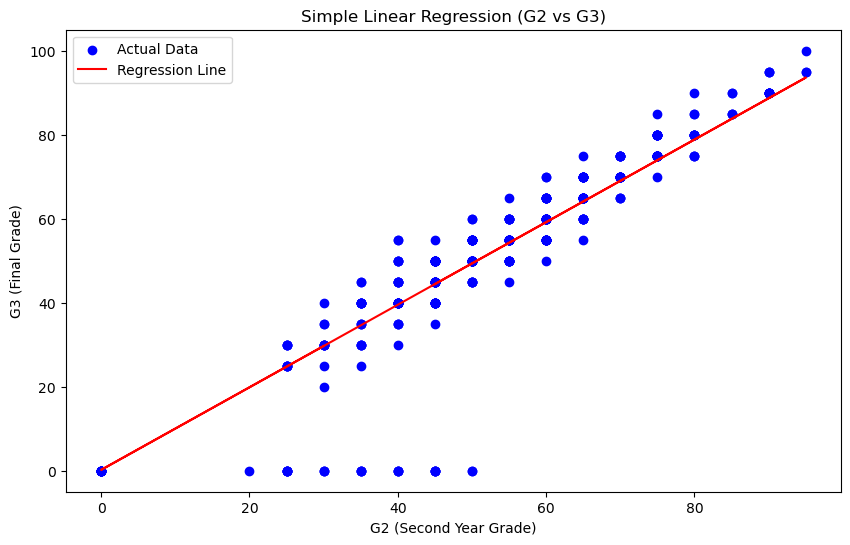

In [ ]:
import matplotlib.pyplot as plt

def gradient_descent_random_init(X, y, learning_rate=0.0001, iterations=1000):
    theta = np.random.rand(X.shape[1]) 
    cost_history = []

    for i in range(iterations):
        gradients = get_gradients(X, y, theta)
        theta = theta - (learning_rate * gradients)
        cost = calculate_mse(X, y, theta)
        cost_history.append(cost)
            
    return theta, cost_history

theta_rand, history_rand = gradient_descent_random_init(X, Y, learning_rate=0.0001, iterations=1000)

print("Weights (Random Init):", theta_rand)

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 1], Y, color='blue', label='Actual Data') # X[:, 1] is G2
plt.plot(X[:, 1], predict(X, theta_rand), color='red', label='Regression Line')
plt.title('Simple Linear Regression (G2 vs G3)')
plt.xlabel('G2 (Second Year Grade)')
plt.ylabel('G3 (Final Grade)')
plt.legend()
plt.show()

Multiple Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
df_multi = pd.read_csv("https://github.com/mishravipul/data/raw/main/multiple_linear_data.csv")

# 2. Preprocessing: Convert Categorical to Numerical
le = LabelEncoder()

# Select columns that are object type (strings)
categorical_cols = df_multi.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_multi[col] = le.fit_transform(df_multi[col])

# 3. Define X and y
# Drop G3 (Target) and G1/G2 (if you want to predict strictly from demographics, 
# but usually grades are kept. The PDF lists all columns as Features 1-19 [cite: 38-59])
X_multi = df_multi.drop(['G3'], axis=1)
y_multi = df_multi['G3']

print("First 5 rows of processed data:")
print(X_multi.head())

First 5 rows of processed data:
   age  address  famsize  reason  studytime  failures  schoolsup  famsup  \
0   18        1        0       0          2         0          1       0   
1   17        1        0       0          2         0          0       1   
2   15        1        1       2          2         3          1       0   
3   15        1        0       1          3         0          0       1   
4   16        1        0       1          2         0          0       1   

   paid  activities  higher  internet  romantic  freetime  goout  health  \
0     0           0       1         0         0         3      4       3   
1     0           0       1         1         0         3      3       3   
2     1           0       1         1         0         3      2       3   
3     1           1       1         1         1         2      2       5   
4     1           0       1         0         0         3      2       5   

   absences  G1  G2  
0         6  25  30  
1         

Train Model and Calculate MSE

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_multi, y_multi)

y_pred = model.predict(X_multi)

mse = mean_squared_error(y_multi, y_pred)
print(f"Mean Squared Error (Multiple Linear Regression): {mse:.4f}")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Mean Squared Error (Multiple Linear Regression): 85.7125
Coefficients: [-0.67485016 -0.5822546   0.4274097   0.34587643 -0.71137308 -1.10365741
  1.96789676  0.32850323  0.48856793 -1.87885935  0.69528954 -0.82558016
 -1.66418764  0.58357191  0.36447447  0.47525622  0.21450393  0.18701464
  0.953764  ]
Intercept: -1.3128392581553712


. Predict on New Data

In [ ]:
new_student = X_multi.iloc[0].values.reshape(1, -1)
new_student[0, 0] = 20 # Change age to 20
new_student[0, 1] = 15 

predicted_grade = model.predict(new_student)
print(f"Predicted Grade for new student: {predicted_grade[0]:.2f}")

Predicted Grade for new student: 16.91


c:\Users\jaisw\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Iteration 0: Cost 1581.5894
Iteration 100: Cost 234.4451
Iteration 200: Cost 72.1708
Iteration 300: Cost 49.4814
Iteration 400: Cost 45.7511
Iteration 500: Cost 44.7673
Iteration 600: Cost 44.2769
Iteration 700: Cost 43.9395
Iteration 800: Cost 43.6866
Iteration 900: Cost 43.4936


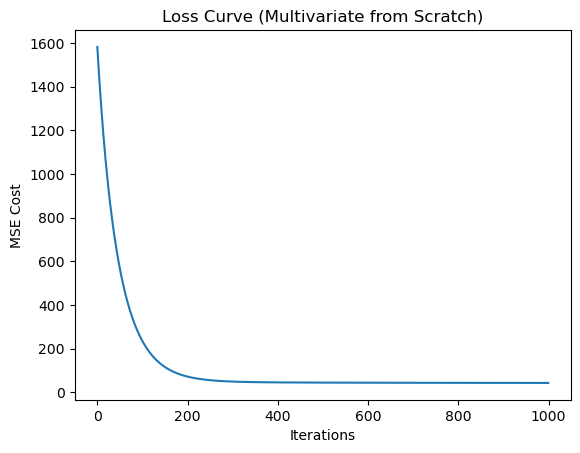

In [ ]:
X_norm = (X_multi - X_multi.mean()) / X_multi.std()
X_norm.insert(0, 'intercept', 1)
X_scratch = X_norm.to_numpy()
y_scratch = y_multi.to_numpy()

theta_multi, history_multi = gradient_descent(X_scratch, y_scratch, learning_rate=0.01, iterations=1000)

plt.plot(history_multi)
plt.title("Loss Curve (Multivariate from Scratch)")
plt.xlabel("Iterations")
plt.ylabel("MSE Cost")
plt.show()